In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from K_means import KMeans

In [51]:
def create_data(n_samples_per_class=200, n_classes=5):
    """    
    Returns:
        X: data (n_samples_per_class * n_classes, 2) 
        y: labels (n_samples_per_class * n_classes,) 
    """
    X_list = []
    for _ in range(n_classes):
        samples = torch.randn(n_samples_per_class, 2)
        offset = 3 * torch.randn(2)
        X_list.append(samples + offset)
 
    X = torch.cat(X_list, dim=0)
    y = torch.cat([torch.full((n_samples_per_class,), label, dtype=torch.long) 
                   for label in range(n_classes)])
    return X, y

n_classes=5
X,y=create_data(n_classes=n_classes)

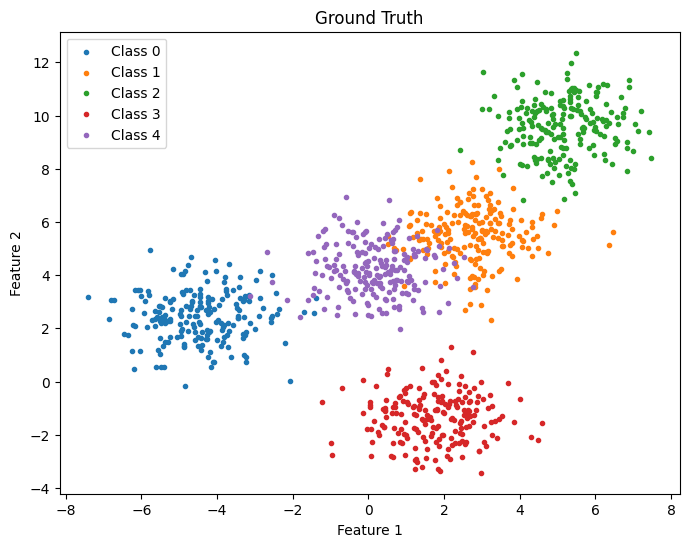

In [52]:
X_np = X.numpy()
y_np = y.numpy()

plt.figure(figsize=(8, 6))

# Ground Truth
plt.title("Ground Truth")
for label in range(n_classes):
    plt.scatter(X_np[y_np == label, 0], X_np[y_np == label, 1], 
                marker='.', label=f'Class {label}')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# K-means

In [53]:
kmeans=KMeans(K=5,iterations=1000)
kmeans.train(X)

In [54]:
y_pred=kmeans.predict(X)

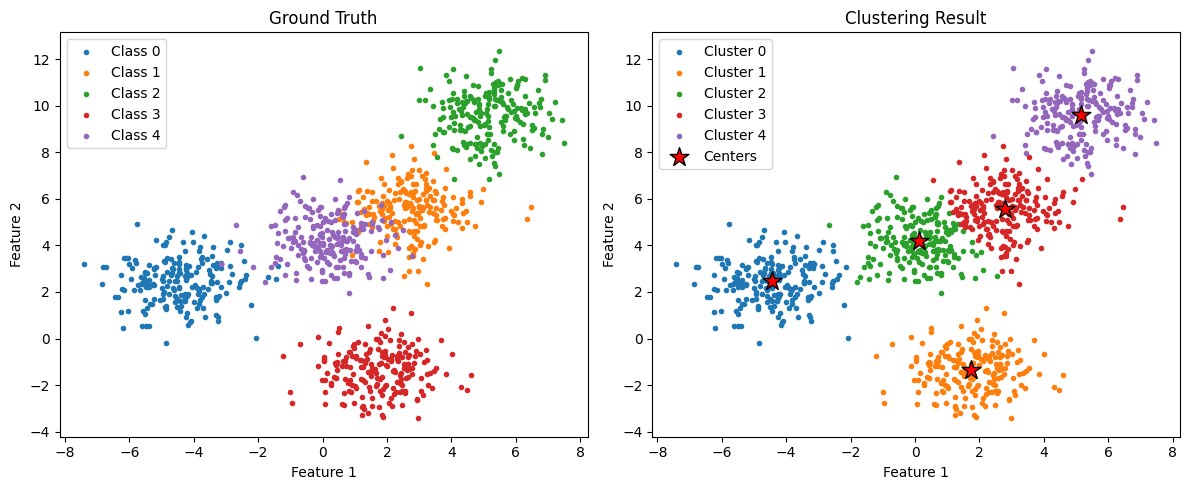

In [56]:
y_pred = np.array(y_pred)          # cluster

plt.figure(figsize=(12, 5))

# left:gt
plt.subplot(1, 2, 1)
plt.title("Ground Truth")
for label in range(n_classes):
    plt.scatter(X_np[y_np == label, 0], X_np[y_np == label, 1],
                marker='.', label=f'Class {label}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# right:cluster
plt.subplot(1, 2, 2)
plt.title("Clustering Result")
for label in range(n_classes):
    plt.scatter(X_np[y_pred == label, 0], X_np[y_pred == label, 1],
                marker='.', label=f'Cluster {label}')
# centers
plt.scatter(kmeans.centers[:, 0], kmeans.centers[:, 1],
            marker='*', s=200, c='red', edgecolors='black', label='Centers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.tight_layout()
plt.show()